# 05 — Building and Training a Simple GAN

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a GAN from scratch: generator + discriminator
- Understand the adversarial training loop in detail (this is the formal GAN lesson the earlier examples previewed)
- Train on a 2-D toy problem where you can *see* the distributions match
- Train on MNIST and generate digit images from pure noise

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 5, lesson 04 "Simple GAN Experiment" — the same adversarial loop you ran in Keras, rewritten with the PyTorch training loop of Course 08 (AIAT 122) — Unit 1 and pushed to real images.

**Used later in:** Course 10 — Unit 1, lessons 06-09 (conditioning, StyleGAN, stabilisation, comparison) and Unit 5, lesson 04.

---

This notebook covers practical activities from **Course 10, Unit 1**:
- Building and training a simple GAN using PyTorch

---

## Introduction

A **GAN** trains two networks against each other:

- the **Generator G**: noise z → fake sample, trying to make fakes indistinguishable from data;
- the **Discriminator D**: sample → probability it is real, trying to catch the fakes.

---

## 🌍 Why this lesson exists — 182 liver-lesion CT scans

Frid-Adar et al. (2018, arXiv 1803.01229) had a real, hard constraint: **182** annotated liver-lesion CT scans, which is what a hospital actually has. They trained a GAN on those scans, added the synthetic lesions to their training set on top of classic augmentation, and reported classification **sensitivity rising from 78.6% to 85.7%** and **specificity from 88.4% to 92.4%**. That is the whole argument for generating data — not "we made pretty pictures", but "we had 182 examples and could not get more".

**What goes wrong without this:** a rare-disease classifier is capped by the number of patients who had the disease *and* consented. Rotating and flipping the same 182 images adds no new information — the classifier sees the same lesions in new orientations. A model that has learned the *distribution* can add variation that rotation cannot produce.


## The Adversarial Training Loop, Step by Step

Every batch runs **two separate updates**:

**1. Discriminator step** — D is a plain binary classifier:
- real batch → target label **1**; fake batch `G(z)` → target label **0**
- `loss_D = BCE(D(real), 1) + BCE(D(G(z).detach()), 0)`
- **`.detach()` matters**: without it, the D step's gradients would also flow into G and *help the generator's opponent train it* — we only want to update D here.

**2. Generator step** — G never sees real data, only D's opinion:
- `loss_G = BCE(D(G(z)), 1)` — G is rewarded when D calls its fakes **real**
- gradients flow *through D* into G, but only G's weights are updated.

**What healthy training looks like:** neither loss goes to zero. If D wins completely (loss_D → 0), G gets no learning signal; if G "wins" too early, it usually means **mode collapse** (G found one sample that fools D and produces only that). Example 08 covers the stabilization tricks (WGAN-GP, spectral norm) used when this balance breaks.


## Part 1 — GAN on a 2-D Toy Problem

Before images, a problem where we can *see* everything: real data is a Gaussian blob centered at (2, 2). Watch the generated (orange) cloud move onto the real (blue) cloud.


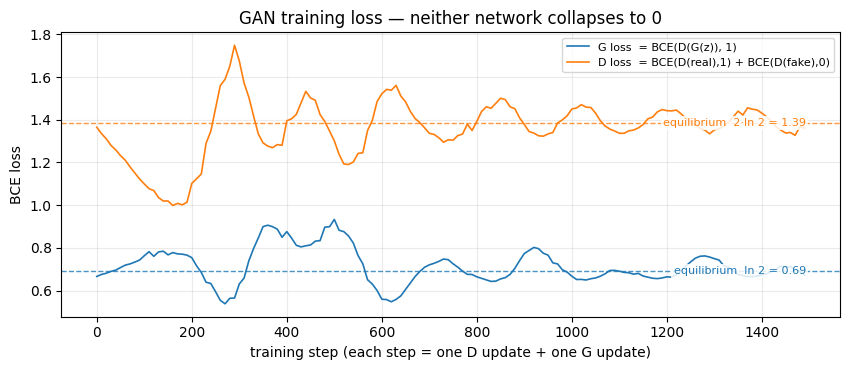

Final G loss: 0.6610  D loss: 1.3927
Real mean: [1.9957735538482666, 2.0193402767181396]  Generated mean: [1.8680000305175781, 1.9579999446868896]


In [1]:
# WHAT/WHY: train a tiny GAN on 2-D points so the adversarial loop is fully
# visible — after training, the generated cloud should sit on the real cloud.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

torch.manual_seed(0)
# ── Real data: 2-D Gaussian blob centered at (2, 2) ──────────────────────
real_data = torch.randn(1000, 2) * 0.5 + torch.tensor([2.0, 2.0])

# ── Tiny generator and discriminator ──────────────────────────────────────
latent_dim = 8
Generator = nn.Sequential(
    nn.Linear(latent_dim, 16), nn.ReLU(),
    nn.Linear(16, 2),
)
Discriminator = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 1), nn.Sigmoid(),
)
opt_G = optim.Adam(Generator.parameters(),     lr=1e-3)
opt_D = optim.Adam(Discriminator.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# ── Storyboard capture: freeze the generator's output at chosen steps, always
# from the SAME 200 latent vectors, so the next cell can show the cloud MOVING
# rather than only where it finished.
SNAPSHOT_STEPS = [0, 100, 300, 600, 1000, 1500]   # step 0 = before any update
# Own generator: the storyboard must not disturb the training random stream.
snap_rng     = torch.Generator().manual_seed(7)
fixed_z_2d   = torch.randn(200, latent_dim, generator=snap_rng)
snapshots_2d = []

# ── Adversarial loop: alternate D step and G step every iteration ─────────
g_losses, d_losses = [], []
batch_size = 64
# Each pass below draws ONE random batch, so each pass is an *iteration* (a single
# weight update), not an epoch (a full pass over the data) - Course 01 (AIAT 111),
# Unit 3, lesson 02. The variable is named `step` here so the two never blur.
for step in range(1500):  # tiny networks — 1500 iterations run in seconds
    if step in SNAPSHOT_STEPS:                     # snapshot BEFORE this update
        with torch.no_grad():
            snapshots_2d.append((step, Generator(fixed_z_2d).numpy()))
    # D step: real → 1, detached fakes → 0
    idx  = torch.randint(0, len(real_data), (batch_size,))
    real = real_data[idx]
    fake = Generator(torch.randn(batch_size, latent_dim)).detach()
    loss_D = criterion(Discriminator(real), torch.ones(batch_size, 1)) + \
             criterion(Discriminator(fake), torch.zeros(batch_size, 1))
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    # G step: make D call fresh fakes "real"
    fake   = Generator(torch.randn(batch_size, latent_dim))
    loss_G = criterion(Discriminator(fake), torch.ones(batch_size, 1))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    g_losses.append(loss_G.item()); d_losses.append(loss_D.item())

with torch.no_grad():                              # final frame, after step 1500
    snapshots_2d.append((1500, Generator(fixed_z_2d).numpy()))

# ── Plot the loss curves against the REAL step number ─────────────────────
# (Where the generated cloud ended up is not drawn here: the next cell shows it
#  as the last frame of the storyboard, and one picture of it is enough.)
# The dashed reference lines are the theoretical equilibrium of this game: if D
# cannot tell real from fake it outputs 0.5 for everything, which makes
#   loss_G = -ln(0.5) = ln 2 ≈ 0.693   and   loss_D = 2·ln 2 ≈ 1.386.
# A healthy GAN hovers around those lines instead of driving either to zero.
with torch.no_grad():
    fake_pts = Generator(torch.randn(200, latent_dim)).numpy()

x_steps = np.arange(0, len(g_losses), 10)      # real step numbers, not an index
fig, ax = plt.subplots(figsize=(8.6, 3.8))
ax.plot(x_steps, g_losses[::10], lw=1.2, color='tab:blue',  label='G loss  = BCE(D(G(z)), 1)')
ax.plot(x_steps, d_losses[::10], lw=1.2, color='tab:orange', label='D loss  = BCE(D(real),1) + BCE(D(fake),0)')
ax.axhline(np.log(2),     color='tab:blue',   ls='--', lw=1, alpha=0.8)
ax.axhline(2 * np.log(2), color='tab:orange', ls='--', lw=1, alpha=0.8)
label_box = dict(fc='white', ec='none', alpha=0.85, pad=1.5)
ax.text(len(g_losses) * 0.995, np.log(2), 'equilibrium  ln 2 = 0.69', bbox=label_box,
        fontsize=8, color='tab:blue', ha='right', va='center')
ax.text(len(g_losses) * 0.995, 2 * np.log(2), 'equilibrium  2·ln 2 = 1.39', bbox=label_box,
        fontsize=8, color='tab:orange', ha='right', va='center')
ax.set_xlabel('training step (each step = one D update + one G update)')
ax.set_ylabel('BCE loss')
ax.set_title('GAN training loss — neither network collapses to 0')
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
print(f'Final G loss: {g_losses[-1]:.4f}  D loss: {d_losses[-1]:.4f}')
print(f'Real mean: {real_data.mean(0).tolist()}  Generated mean: {fake_pts.mean(0).round(3).tolist()}')


**Read the loss curves.** Neither line goes to zero, and neither line goes to infinity — they oscillate around the two dashed lines for the rest of the run. Those lines are not drawn by eye: they are where the game ends up when the discriminator genuinely cannot tell real from fake and answers 0.5 to everything, which makes G's loss ln 2 = 0.69 and D's loss 2·ln 2 = 1.39. The printed final values, G 0.66 and D 1.39, land essentially on them.

The wobble is the two networks taking turns. Every time D pulls ahead its loss dips and G's rises; G adapts, and the pair swaps. **A loss curve like this looks like nothing is happening** — and the storyboard in the next cell shows that a great deal was. That is why "the loss is flat" is never enough evidence about a GAN, and why every GAN lesson in this unit shows you samples as well as numbers.

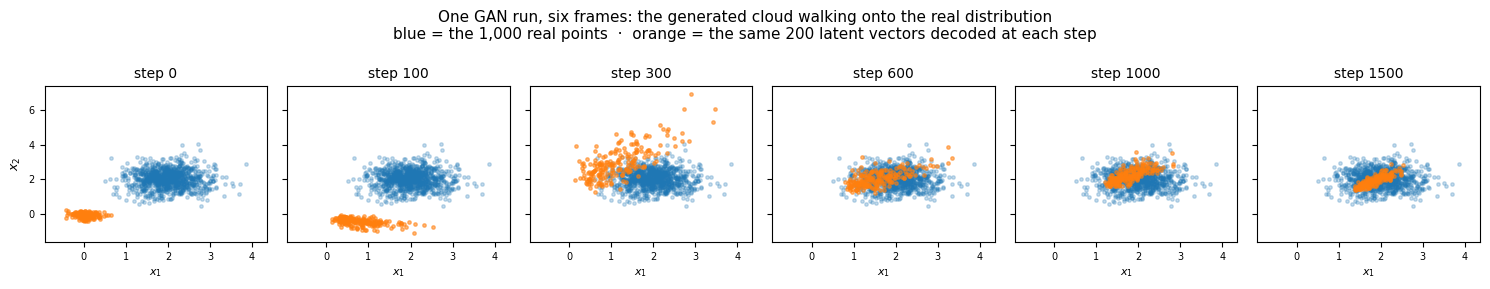

step    generated mean        distance to real mean   generated std
   0    (+0.04, -0.07)          2.866                 (0.18, 0.13)
 100    (+0.80, -0.45)          2.742                 (0.44, 0.20)
 300    (+1.17, +2.98)          1.269                 (0.63, 0.94)
 600    (+1.57, +2.05)          0.426                 (0.51, 0.44)
1000    (+1.80, +2.25)          0.304                 (0.34, 0.39)
1500    (+1.83, +1.91)          0.201                 (0.27, 0.31)
real    (+2.00, +2.02)          0.000                 (0.50, 0.52)


In [2]:
# WHAT/WHY: the promise at the top of Part 1 was "watch the generated cloud
# move onto the real cloud". The loss curve above cannot show that, so here is
# the movement itself: six frames from the run you just trained, each decoding
# the SAME 200 latent vectors at a different point in training. The last frame
# is also the answer to "where did it end up?".
real_np = real_data.numpy()
all_pts = np.vstack([pts for _, pts in snapshots_2d] + [real_np])
lims = [all_pts.min(0) - 0.5, all_pts.max(0) + 0.5]

fig, axes = plt.subplots(1, len(snapshots_2d), figsize=(15, 2.9),
                         sharex=True, sharey=True)
for ax, (step, pts) in zip(axes, snapshots_2d):
    ax.scatter(real_np[:, 0], real_np[:, 1], s=6, alpha=0.25, c='tab:blue')
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.55, c='tab:orange')
    ax.set_xlim(lims[0][0], lims[1][0]); ax.set_ylim(lims[0][1], lims[1][1])
    ax.set_title(f"step {step}", fontsize=10)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("$x_1$", fontsize=8)
axes[0].set_ylabel("$x_2$", fontsize=9)
plt.suptitle("One GAN run, six frames: the generated cloud walking onto the real distribution\nblue = the 1,000 real points  ·  orange = the same 200 latent vectors decoded at each step", fontsize=11)
plt.tight_layout(); plt.show()

# ── Printed step table: how far the generated cloud still is from the data ──
real_mean = real_np.mean(0)
print("step    generated mean        distance to real mean   generated std")
for step, pts in snapshots_2d:
    d = float(np.linalg.norm(pts.mean(0) - real_mean))
    print(f"{step:>4}    ({pts.mean(0)[0]:+.2f}, {pts.mean(0)[1]:+.2f})"
          f"          {d:.3f}                 ({pts.std(0)[0]:.2f}, {pts.std(0)[1]:.2f})")
print(f"real    ({real_mean[0]:+.2f}, {real_mean[1]:+.2f})"
      f"          0.000                 ({real_np.std(0)[0]:.2f}, {real_np.std(0)[1]:.2f})")

**Read the frames left to right.** In the first frame the generator is untrained: all 200 latent vectors land in one tight clump below and to the left of the blue data — the "distribution" it represents is barely a dot. By step 100 the clump has stretched but has not left that corner. Between steps 100 and 300 it crosses the gap and *overshoots*, spraying points above and to the right of the real cloud. The last three frames pull back and settle inside the blue.

The printed table is the same journey in numbers: the distance from the generated mean to the real mean falls at every snapshot, 2.87 → 2.74 → 1.27 → 0.43 → 0.30 → 0.20. Location is learned, and quickly.

Now look at the final frame critically. The orange points sit in the right place but form a **thin diagonal streak**, not a round cloud, and the table says the same thing: generated standard deviations of about (0.27, 0.31) against the real (0.50, 0.52). The generator matched the *location* of the data long before the *spread*, and after 1,500 steps it still has not — a tiny 2-layer generator has squeezed most of its 8-dimensional noise onto roughly one direction. That is mode collapse in its mildest visible form, and it is the failure examples 08 and 09 attack.

This frame grid is also the honest way to read the loss curves in the previous figure. Losses that wobble around a constant value look like nothing is happening; the frames show that a great deal was.

## Part 2 — 🌍 Real-World Worked Example: GAN Generating Handwritten Digits

**Industry context:**
- GANs generate synthetic training data for autonomous-vehicle datasets
- Pharmaceutical research uses GANs to propose molecular structures
- Design teams use GAN-generated imagery for rapid mockups

Same loop as Part 1, scaled to images. This is a small **fully-connected GAN** (a real DCGAN uses convolutional layers — see references). We train 5 quick CPU epochs for classroom speed, so expect *blurry but digit-like* samples.


Epoch 1/5 — D_loss=0.8774  G_loss=1.4142


Epoch 2/5 — D_loss=0.6754  G_loss=2.3134


Epoch 3/5 — D_loss=0.6331  G_loss=2.4956


Epoch 4/5 — D_loss=0.5972  G_loss=2.5694


Epoch 5/5 — D_loss=0.5101  G_loss=2.8917


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_52262/821833730.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


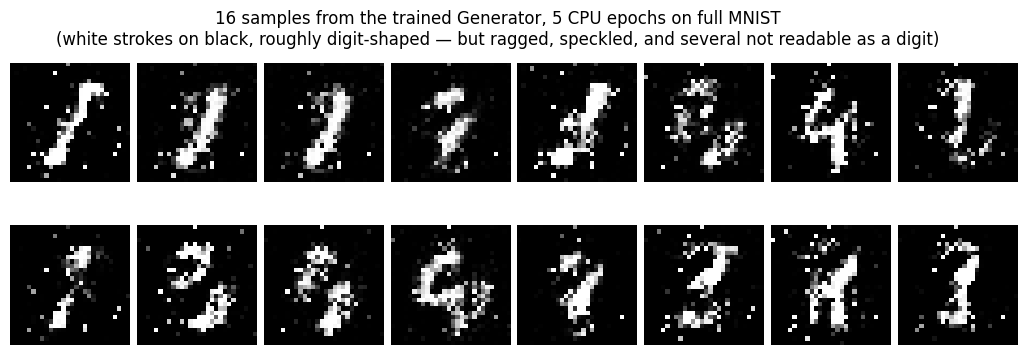

Longer training (20+ epochs) and convolutional layers (DCGAN) sharpen these a lot — try it.


In [3]:
# WHAT/WHY: the exact adversarial loop from Part 1, applied to MNIST images.
# The generated-sample figure at the end is the deliverable: digits from noise.
import torchvision, torchvision.transforms as T

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Data scaled to [-1, 1] to match the generator's Tanh output ───────────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise (64) → flattened 28×28 image ─────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: flattened image → probability real ─────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
EPOCHS = 5  # ~25 s on CPU; raise for sharper samples
for epoch in range(EPOCHS):
    epoch_d, epoch_g = [], []
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # D step: real → 1, detached fakes → 0
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # G step: fool D with fresh fakes
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
        epoch_d.append(loss_D.item()); epoch_g.append(loss_G.item())
    d_losses.append(sum(epoch_d)/len(epoch_d))
    g_losses.append(sum(epoch_g)/len(epoch_g))
    print(f"Epoch {epoch+1}/{EPOCHS} — D_loss={d_losses[-1]:.4f}  G_loss={g_losses[-1]:.4f}")

# ── Generate 16 digits from pure noise and SHOW them inline ───────────────
G.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM)
    fake_imgs = G(z).view(-1, 28, 28).cpu().numpy()

# hspace keeps a visible gap between the two rows — without it the black
# backgrounds merge and 16 square digits read as 8 tall ones.
fig, axes = plt.subplots(2, 8, figsize=(13, 4),
                         gridspec_kw=dict(hspace=0.12, wspace=0.06))
for ax, img in zip(axes.flatten(), fake_imgs):
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1); ax.axis('off')
plt.suptitle("16 samples from the trained Generator, 5 CPU epochs on full MNIST\n(white strokes on black, roughly digit-shaped — but ragged, speckled, and several not readable as a digit)")
plt.tight_layout(); plt.show()
print("Longer training (20+ epochs) and convolutional layers (DCGAN) sharpen these a lot — try it.")


**Read the digit grid — and be strict about it.** What the generator has clearly learned is the *format* of MNIST: white ink on a black field, one connected mass of stroke, roughly centred, roughly the right thickness. Nobody encoded that; it came entirely from the discriminator rejecting anything else.

What it has *not* learned is a digit alphabet. Some panels read as a 1 or a 7 at a glance; others are stroke-shaped scribbles that are not any digit, and every panel carries a scatter of bright single-pixel speckle that no handwriting produces. Five epochs of a fully-connected generator on CPU buys the format, not the content.

This is the same claim the 2-D frames made, in a harder space: **location before spread, format before detail**. Example 08 stabilises this loop, and Unit 3 replaces the architecture with convolutional and diffusion models that actually close the gap. Do not leave this lesson believing you have seen a working digit generator — you have seen the mechanism that becomes one.

## 💬 Discuss

1. Our 2-D GAN matched the real mean to within **0.14 in both coordinates** (real [2.00, 2.02] vs generated [1.87, 1.96]). Is matching means and spreads enough to call a generator "correct"? Name the next thing you would measure, and say what failure it would catch that the means miss.
2. Frid-Adar's synthetic lesions fed a classifier used on patients. Suppose the GAN quietly dropped the rarest lesion subtype: the classifier gets worse at exactly the case that matters, and the reported accuracy still goes *up* because the rare subtype is rare in the test set too. How would you catch that before deployment?
3. Neither loss went to zero here (final G 0.66, D 1.39). A classmate reports **D loss 0.01, G loss 8.0** and says training is going well because D is very accurate. What do you tell them is actually happening?


## ⚠️ Where this breaks

**No likelihood, ever.** A GAN gives you no p(x). You cannot ask it "is this sample typical?", you cannot compute held-out log-likelihood, and you cannot compare two GANs the way example 03 compared two GMMs. Every evaluation becomes indirect — FID, sample grids, downstream accuracy — and example 10 shows how much that indirection costs you.

**Losses are not progress bars.** In an adversarial game a falling generator loss can mean the generator is winning by mode-collapsing onto one output that reliably fools D. Only samples and explicit coverage checks tell you which it is; example 08 measures coverage directly.

**Never evaluate on generated data.** Using a GAN to manufacture training data for a rare class is legitimate; using GAN samples in the *test* set is not. The generator can only redistribute what was in the 182 real scans, so a test set drawn from it will certify the model against the generator's blind spots rather than against reality.

**Cheaper alternative:** when the transformation you need is known — rotation, crop, brightness, elastic deformation — classic augmentation costs nothing, converges immediately, and cannot invent a lesion that never existed. Reach for a GAN when the variation you need is not expressible as a known transform.


---

## 🔭 State of the field (2026)

*Enrichment, not examinable content — the official unit examines the technique above exactly as it is taught. This box says where that technique sits on the 2026 map.*

The adversarial loop you just wrote is no longer how production image and video generators are trained. The
dominant recipe replaces the min-max game with a plain regression — predict the noise, or the velocity that
carries noise to data, then integrate it at sampling time — and runs it inside a learned latent space (Esser
*et al.* 2024). The honest footnote is that this happened for reasons of scale and controllability, *not*
because GANs turned out to be untrainable: a NeurIPS 2024 paper derives a well-behaved regularized relativistic
loss, discards the entire bag of ad-hoc tricks, and reports that the resulting minimalist baseline surpasses
StyleGAN2 on FFHQ, ImageNet, CIFAR and Stacked MNIST (Huang *et al.* 2025). The adversarial idea also survives
*inside* the new stack — one of the standard fast-sampling methods adds a GAN loss to diffusion distillation so
the student can be trained against real images (Yin *et al.* 2024).

**Why building this one by hand is still exactly the right thing to learn.** The GAN is the clearest working
example of an **implicit** generative model: no likelihood, no explicit density, a sampler judged only by
another network — which is why the ⚠️ section's "no p(x), ever" lands so hard here and nowhere else. Everything
you measured in this notebook — the two-update-per-batch structure, the non-saturating generator loss, losses
that oscillate around a fixed point instead of descending — is the vocabulary the rest of the unit and Unit 4's
deepfake-detection lesson are written in. It is also what the official plan examines.

**Read:** Esser *et al.* (2024), <https://arxiv.org/abs/2403.03206> · Huang *et al.* (2025),
<https://arxiv.org/abs/2501.05441> (both listed below).

---

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434) *(the convolutional upgrade of this notebook's architecture)*
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**Next in this unit:** conditional GANs (06), StyleGAN ideas (07), training stabilization (08)

**Recent (2024–2026):**
- Huang et al. (2025) — [The GAN is dead; long live the GAN! A Modern GAN Baseline](https://arxiv.org/abs/2501.05441) *(NeurIPS 2024 — a regularized relativistic loss with local convergence guarantees, which lets R3GAN discard the whole bag of ad-hoc tricks)*
- Esser et al. (2024) — [Scaling Rectified Flow Transformers for High-Resolution Image Synthesis](https://arxiv.org/abs/2403.03206) *(what trains today's image generators instead of a min-max game: regress the path from noise to data, then integrate it)*
- Oganov et al. (2025) — [GAS: Improving Discretization of Diffusion ODEs via Generalized Adversarial Solver](https://arxiv.org/abs/2510.17699) *(where the adversarial loop went: a parameterized ODE sampler trained with distillation plus an adversarial term, which the authors credit with removing artifacts and restoring fine detail)*


## 📝 Summary

In **05 — Building and Training a Simple GAN** you implemented the full adversarial loop — D step (real=1, detached fakes=0), G step (fool D) — watched a 2-D generator move its cloud onto the real distribution, and generated MNIST digits from pure noise (both figures are in this notebook's outputs). You also learned what healthy loss curves look like and why `.detach()` is required in the D step. Example 06 adds label control; example 08 fixes this loop when it breaks.
